In [1]:
import pandas as pd
import numpy as np
from collections import Counter
from collections import defaultdict
from matplotlib import pyplot as plt

#custom functions
from heuristic_functions import calculate_coverage_and_ratios
from heuristic_functions import get_manufacturer_vaccine_price
from heuristic_functions import build_tenders_partial

In [2]:
%run initialize_heuristic_data.py

In [6]:
%who
tender_cost = 1e8

A	 A_p	 A_v	 Counter	 P	 P_a	 P_v	 V	 V_a	 
V_p	 antigens	 build_tenders_partial	 calculate_coverage_and_ratios	 capacity_data	 capacity_path	 columns	 data	 defaultdict	 
delta	 demand_80	 demand_80_expanded	 demand_80_final	 demand_path	 f_start	 file_path	 get_manufacturer_vaccine_price	 i_start	 
inventory_DF	 max_tender_length	 missed_doses	 money_path	 np	 pd	 plt	 price_data	 ratio_DF	 
s_start	 sheet_names	 tender_cost	 tender_schedules	 total_price	 vaccine_consumption_percent	 vaccine_purchases	 years	 


In [4]:
# extend demand to get over range error when creating a new tender
demand_80_MCV = demand_80_final
replicated_columns = pd.concat([demand_80_MCV.iloc[:, 9]] * 10, axis=1)
replicated_columns.columns = range(11, 21)
demand_80_MCV = pd.concat([demand_80_MCV, replicated_columns], axis=1)
#create interim demand for tracking
interim_demand_DF = demand_80_MCV.copy()

#extend capacity data to fix range error
replicated_columns = pd.concat([capacity_data.iloc[:, 9]] * 10, axis=1)
replicated_columns.columns = range(11, 21)
capacity_data = pd.concat([capacity_data, replicated_columns], axis=1)
capacity_data

#extend price data to fix range error
for vaccine, df in price_data.items():
    replicated_columns = pd.concat([df.iloc[:, -1]] * 10, axis=1)  # Replicate the last column (year 10)
    replicated_columns.columns = range(11, 21)  # Rename columns 11-20
    price_data[vaccine] = pd.concat([df, replicated_columns], axis=1)  # Concatenate with the original dataframe

#create tender schedule tracker, make start 0 indexed
tender_schedules_MCV = tender_schedules
tender_schedules_MCV['Starting'] -= 1 
tender_schedules_MCV['Fill'] = 'Initial'

missed_doses_MCV = missed_doses
ratio_DF_MCV = pd.DataFrame()
inventory_DF_MCV = inventory_DF

#logic to setup least covered antigens:
# Flatten the list of all antigens from all vaccines
all_antigens = [antigen for antigens in A_v.values() for antigen in antigens]
# Count the occurrences of each antigen
antigen_counts = Counter(all_antigens)
# least_covered_antigens = sorted(antigen_counts.keys(), key=lambda x: antigen_counts[x], reverse=False)

max_tender_length = 5

In [5]:
tender_schedules_MCV

,Antigen,Starting,Ending,Fill
0,Measles,0,3,Initial
1,Mumps,0,3,Initial
2,Rubella,0,3,Initial
3,Diphtheria,0,1,Initial
4,Tetanus,0,1,Initial
5,Pertussis,0,1,Initial
6,Hib,0,1,Initial
7,Hepatitis_B,0,1,Initial
8,Polio,0,1,Initial
9,HPV,0,5,Initial


In [6]:
def build_tenders_partial(antigen, interim_demand, capacity_data, inventory_DF, year, max_tender_length, total_price, A_v, antigen_list):
    tender_start = year
    inventory_used
    new_tender = None
    if year not in capacity_data.columns:
        print(f"Year {year} is not valid. Exiting function.")
        return {
            'Inventory_Used': [],
            'Demand_Filled': 0,
            'Demand_unfilled': [],
            'Total_Price': total_price,
            'Message': "Invalid year",
        }

    for tender_year in range(year + 1, year + max_tender_length): 
        print(f"CHECKING YEAR: {tender_year} FOR CAPACITY!")
        # Check the demand
        if antigen in interim_demand.iloc[:, 0].tolist():
            antigen_demand = interim_demand.loc[interim_demand['antigen'] == antigen, tender_year].iloc[0]
            starting_antigen_demand = interim_demand.loc[interim_demand['antigen'] == antigen, tender_year].iloc[0]
            # print(f"antigen {antigen} demand: {antigen_demand} in year {tender_year}")
        else:
            raise ValueError(f"Antigen '{antigen}' not found in the list of antigens.")

        print(f"can we find supply enough for {antigen}?????")
        # for the antigen, is there supply of a vaccine that can cover it?
        price_list = get_manufacturer_vaccine_price(row.loc['antigen'], price_data, V_a, P_v, tender_year)

        #sort price list based on most coverage, to least coverage


        for entry in price_list: #tenders can cover partial demand, so we need to update for that and also for othe antigen demands filled
            print(f"ENTRY: {entry['Vaccine']}")
            manufacturer = entry['Manufacturer']
            vaccine = entry['Vaccine']
            price = entry['Price'] # need to track cost still

            #supply
            manufacturer_row = capacity_data[capacity_data['Manufacturer'] == manufacturer]
            if not manufacturer_row.empty:
                # capacity = manufacturer_row.iloc[0][year]
                capacity = capacity_data.loc[capacity_data['Manufacturer']==manufacturer, tender_year].iloc[0]
                # print(f"Current capacity: {capacity} for {manufacturer}")
            else:
                raise ValueError(f"Manufacturer '{manufacturer}' not found in the list of manufacturers.")
                        
            # print(antigen_demand)
            if capacity > antigen_demand: #we need to update inventory based on teh vaccine, so that we cover all antigens in all vaccines tendered for
                interim_demand.loc[interim_demand['antigen'] == antigen, tender_year] = 0
                capacity_data.loc[capacity_data['Manufacturer'] == manufacturer, year] = max(capacity_data.loc[capacity_data['Manufacturer'] == manufacturer, tender_year].iloc[0] - antigen_demand, 0)
                print(f"! Updated {antigen} demand: {interim_demand.loc[interim_demand['antigen'] == antigen, tender_year].iloc[0]} using {vaccine} by {antigen_demand}")
                inventory_DF.loc[inventory_DF['Vaccine'] == vaccine, 'Amount'] += antigen_demand
                break
            elif capacity > 0 and antigen_demand > capacity:
                interim_demand.loc[interim_demand['antigen'] == antigen, tender_year] = max(interim_demand.loc[interim_demand['antigen'] == antigen, tender_year].iloc[0] - capacity, 0)
                print(f"Modified {antigen} demand: {interim_demand.loc[interim_demand['antigen'] == antigen, tender_year].iloc[0]} using {vaccine} by {capacity}")
                capacity_data.loc[capacity_data['Manufacturer'] == manufacturer, tender_year] = 0
                inventory_DF.loc[inventory_DF['Vaccine'] == vaccine, 'Amount'] += capacity
            else:
                print("this should be no capacity left...")
                print(f"the capacity for {manufacturer} is {capacity}")

                

        if interim_demand.loc[interim_demand['antigen'] == antigen, tender_year].iloc[0] == 0:
            print(f"Year {tender_year}: Demand fully met.")
            new_tender = {
                'Antigen': antigen,
                'Starting': year,
                'Ending': tender_year+1,
                'Fill': 'Fully'
            }
            tender_price = (new_tender['Ending'] - new_tender['Starting'])*tender_cost
            results = {
            'Inventory_Used': inventory_used,
            'Demand_Filled': 0,
            'Demand_unfilled': [],
            'Total_Price': total_price,
            'Message': f"Year {tender_year}: Demand fully met.",
            }
            new_tender = pd.DataFrame([new_tender])
        elif starting_antigen_demand > interim_demand.loc[interim_demand['antigen'] == antigen, tender_year].iloc[0]:
            print(f"Year {tender_year}: Demand partially met.")
            new_tender = {
                'Antigen': antigen,
                'Starting': year,
                'Ending': tender_year+1,
                'Fill': 'Partial'
            }
            new_tender = pd.DataFrame([new_tender])
            tender_price = (new_tender['Ending'] - new_tender['Starting'])*tender_cost
            results = {
            'Inventory_Used': [],
            'Demand_Filled': 0,
            'Demand_unfilled': [],
            'Total_Price': total_price,
            'Message': f"Year {tender_year}: Demand partially met.",
            }
            break
        else:
            print(f"Year {tender_year}: Demand Not Met")
            new_tender = {
                'Antigen': antigen,
                'Starting': year,
                'Ending': tender_year+1,
                'Fill': 'None'
            }

            results = {
            'Inventory_Used': [],
            'Demand_Filled': 0,
            'Demand_unfilled': [],
            'Total_Price': 0,
            'Message': f"Year {tender_year}: Demand Not Met",
            }
            new_tender = pd.DataFrame([new_tender])
            break



    return new_tender

In [7]:
for year in range(1, 11):  # Iterate through each year - short range for testing  range(1,len(demand_80_MCV.columns)-1)
    print("********************HAPPY NEW YEAR****************************")
    print("******************Reticulating splines...**************************")
    print(f"Year: {year}")

    least_covered_antigens = sorted(antigen_counts.keys(), key=lambda x: antigen_counts[x], reverse=False)
    # least_covered_antigens = least_covered_antigens.reverse()
    # least_covered_antigens = list(antigen_counts.keys())

    remaining_inventory = {}
    uncovered_demand = {}
    # print(f"least covered antigens: {least_covered_antigens}")
    while least_covered_antigens:  # Iterate through each antigen, find what vaccines cover each antigen, least to greatest, update supply and demand
        print('###############################################################')
        antigen = least_covered_antigens.pop(0)
        # print(f"serving antigen {antigen}")
        # print(f"Initial Demand: {demand_80_MCV.loc[demand_80_MCV['antigen'] == antigen, year].iloc[0]} for {antigen}")
        # print(f"Initial Inventory of vaccine covering {antigen}: {inventory_DF_MCV}")
        # print(f"A_v items are: {A_v.items()}")
        for vaccine, antigens in A_v.items():  # Iterate through A_v to check which vaccines cover the antigen
            # print(f"antigens list is: {antigens}")
            if antigen in antigens and demand_80_MCV.loc[demand_80_MCV['antigen'] == antigen, year].iloc[0] > 0:
                # print(f"{antigen} FOUND in {vaccine}")
                vaccine_inventory_value = inventory_DF_MCV.loc[inventory_DF_MCV['Vaccine'] == vaccine, 'Amount'].iloc[0]
                antigen_demand_value = demand_80_MCV.loc[demand_80_MCV['antigen'] == antigen, year].iloc[0]

                difference = vaccine_inventory_value - antigen_demand_value

                if difference >= 0: #
                    remaining_inventory[vaccine] = difference
                    decrement = antigen_demand_value
                else: 
                    remaining_inventory[vaccine] = 0
                    decrement = vaccine_inventory_value
                    uncovered_demand[antigen] = abs(difference)

                # print("^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^")
                inventory_DF_MCV.loc[inventory_DF_MCV.iloc[:, 0] == vaccine, 'Amount'] = remaining_inventory[vaccine]
                # print(f"Adjusted Inventory of {vaccine} covering {antigen}: {inventory_DF_MCV}")

                # print("Decrementing antigen demands")
                for ant in antigens:
                    # print(f"antigen to decrement: {ant}")
                    current_demand = demand_80_MCV.loc[demand_80_MCV["antigen"] == ant, year].iloc[0]
                    if current_demand > 0:
                        demand_80_MCV[year] = demand_80_MCV[year].astype(float)
                        demand_80_MCV.loc[demand_80_MCV["antigen"] == ant, year] = max(current_demand - decrement, 0)
                        # print(f"post decrement {ant} demand: {demand_80_MCV.loc[demand_80_MCV['antigen'] == ant, year].iloc[0]}")
            # else antigen in antigens and demand_80_MCV.loc[demand_80_MCV['antigen'] == antigen, year].iloc[0] <= 0:
            #     print(f"Demand for {antigen} is {demand_80_MCV.loc[demand_80_MCV['antigen'] == antigen, year].iloc[0]}!")
            #     print()


        print(f"{len(antigen_counts)} antigens entered, only {len(least_covered_antigens)} remain!")

    #update any uncovered demand, to next year. add uncovered demand to dosses_missed dict
    if 'uncovered_demand' in locals(): # Check if the variable exists
        while uncovered_demand:
            top = uncovered_demand.popitem()
            top_antigen = top[0]
            doses_missed = top[1]
            # print(f"{doses_missed} doses missed for {top_antigen}")
            demand_80_MCV.loc[demand_80_MCV.iloc[:, 0] == top_antigen, demand_80_MCV.columns[year+1]] += int(doses_missed)
            missed_doses_MCV.loc[missed_doses_MCV.iloc[:, 0] == top_antigen, missed_doses_MCV.columns[1]] += int(doses_missed)
            ###################################################################################################################
            #Need to add logic here to update interim_demand_DF[year +1]  with any uncovered demand
            interim_demand_DF.loc[interim_demand_DF.iloc[:,0]==top_antigen, demand_80_MCV.columns[year+1]] += int(doses_missed)
    else:
        print("no uncovered demand this year")
    
    #check ratio for supply/demand.
    #check at end of year for math reasons. if ratio is less than 1, schedule tender, perform search for vaccines, add inventory
    # print(f"Checking ratio of supply to demand for antigens for year {year + 1}!")
    # print()
    #pulls the current ratio of supply and demand. returns ratio_DF and antigen coverage DF
    ratio_DF_MCV, coverage_df = calculate_coverage_and_ratios(inventory_DF_MCV, demand_80_MCV, V_a, year+1)

    ratio_DF_MCV = ratio_DF_MCV.sort_values(by='antigen', key=lambda x: x.map(antigen_counts), ascending=True)

    for index, row in ratio_DF_MCV.iterrows():
        if row['Ratio'] < 1.0:  # Antigen needs a tender
            print("$*$*$*$*$*$*$*$*$*$*$*$*$*$*$*$*$*$*$*$*$$*$*$*")
            print(f"Generating Tender for {row.loc['antigen']}")
            #execute tender function
            result = build_tenders_partial(row.loc['antigen'], interim_demand_DF, capacity_data, inventory_DF_MCV, year, max_tender_length, total_price, A_v, A)
            print(f"the result of the tender is {result}")
            #needs to handle None for new tender
            if result is not None:
                #need to call result['new_tender'] when we update the return call
                tender_schedules_MCV = pd.concat([tender_schedules_MCV, pd.DataFrame(result)], ignore_index=True)
            else:
                continue

        else:  # Supply meets demand
            print(f"Supply >= demand for {row.loc['antigen']}, Ratio: {round(row.loc['Ratio'], 2)}")


********************HAPPY NEW YEAR****************************
******************Reticulating splines...**************************
Year: 1
###############################################################
12 antigens entered, only 11 remain!
###############################################################
12 antigens entered, only 10 remain!
###############################################################
12 antigens entered, only 9 remain!
###############################################################
12 antigens entered, only 8 remain!
###############################################################
12 antigens entered, only 7 remain!
###############################################################
12 antigens entered, only 6 remain!
###############################################################
12 antigens entered, only 5 remain!
###############################################################
12 antigens entered, only 4 remain!
###########################################################

In [17]:
capacity_data.iloc[:, :11]

,Manufacturer,1,2,3,4,5,6,7,8,9,10
0,AJ_Vaccines,7711003,0,0,0,0,0,0,0,7711003,0
1,BB_NCIPD,39223956,0,0,0,0,0,0,0,0,0
2,Bharat_Biotech,61029105,0,0,0,0,0,0,0,0,0
3,Bilthoven,12048153,0,0,0,0,0,0,0,12048153,0
4,Biological_E,164885690,0,0,0,0,0,0,0,0,0
5,China_National,12812242,0,0,0,0,0,0,0,0,0
6,GSK,226762686,0,0,0,162058886,0,0,0,226762686,0
7,Haffkine_Bio,80972855,0,0,0,0,0,0,0,0,0
8,LG_Chem,43702188,0,0,0,0,0,0,0,0,0
9,Merck_Sharp,56991052,56991052,56991052,56991052,23260552,0,56991052,56991052,56991052,56991052


In [8]:
tender_schedules_MCV.loc[tender_schedules_MCV['Antigen'] == 'Diphtheria']
# tender_schedules_MCV

,Antigen,Starting,Ending,Fill
3,Diphtheria,0,1,Initial
17,Diphtheria,1,3,Partial
22,Diphtheria,2,4,Partial
30,Diphtheria,3,5,Partial
38,Diphtheria,4,6,Partial
50,Diphtheria,5,7,Partial
55,Diphtheria,6,8,Partial
60,Diphtheria,7,9,Partial
66,Diphtheria,8,10,Partial
74,Diphtheria,9,11,Partial


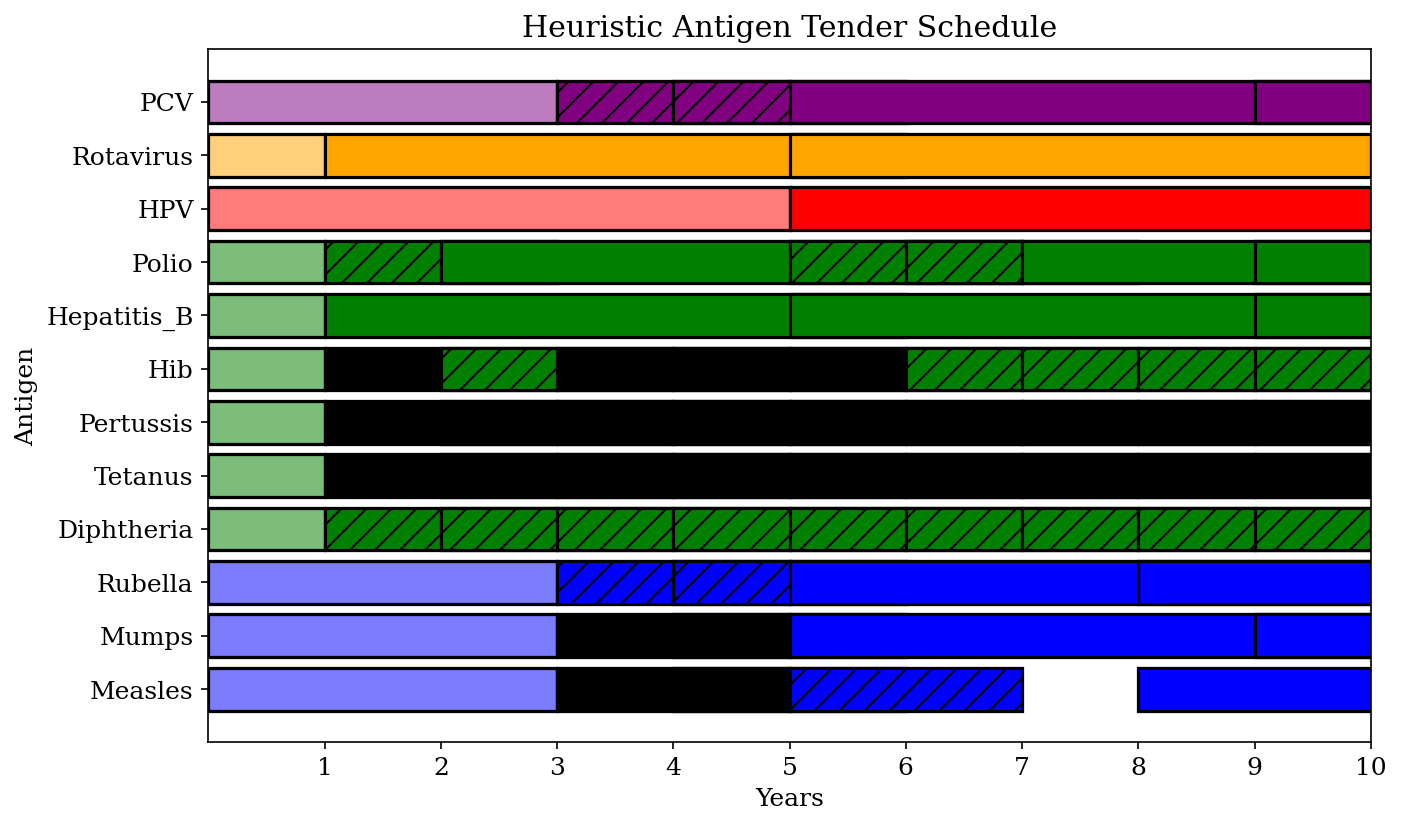

In [9]:
# Full script combining the color formatting and the black outline updates

import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd

df = tender_schedules_MCV

# Define color groups
colors = {
    "MMR Antigens": "blue",
    "MMR":"grey",
    "Hexa Antigens": "green",
    "Penta":"brown",
    "HPV": "red",
    "PCV": "purple",
    "Rota": "orange",
}

color_groups = {
    "MMR Antigens": ["Measles", "Mumps", "Rubella"],
    "MMR" : ["MMR"],
    "Hexa Antigens": ["Diphtheria", "Tetanus", "Pertussis", "Hib", "Polio", "Hepatitis_B"],
    "Penta":["Penta"],
    "HPV": ["HPV"],
    "PCV": ["PCV"],
    "Rota": ["Rotavirus"],
}

# Creating a color mapping for each antigen
antigen_colors = {}
for group, antigen_list in color_groups.items():
    for antigen in antigen_list:
        antigen_colors[antigen] = colors[group]

df['Color'] = df['Antigen'].map(antigen_colors)

# Plot configuration
plt.rcParams.update(mpl.rcParamsDefault)
plt.rcParams.update(
    {
        "font.family": "serif",
        "font.size": 12,
        "font.weight": "normal",
        "figure.titlesize": "medium",
        "xtick.color": "black",
        "ytick.color": "black",
        "axes.labelcolor": "black",
        "text.color": "black",
        "savefig.dpi": 300,
        "figure.dpi": 150,
        "savefig.bbox": "tight",
    }
)

# Plot the horizontal bar chart with color formatting and black outlines for each segment
plt.figure(figsize=(10, 6))
for i, row in df.iterrows():
    color = row['Color']
    if row['Starting'] == 0:
        color = mpl.colors.to_rgba(color, 0.3)  # Darken by reducing transparency
    
    if row["Fill"] == 'Partial':
        hatch = '//'
    elif row['Fill'] == 'None':
        color = 'black'
        hatch = None
    else:
        hatch = None
    
    # Add black outlines for separate segments
    plt.barh(row['Antigen'], row['Ending'] - row['Starting'], left=row['Starting'], 
             color=color, edgecolor='black', linewidth=1.5, hatch=hatch)


    # Plot the bar with the corresponding properties
    plt.barh(row['Antigen'], row['Ending'] - row['Starting'], 
             left=row['Starting'], color=color, edgecolor='black', 
             linewidth=1.5, hatch=hatch)

plt.xlim(0, 10) 
plt.xticks(list(range(1, 11)))
plt.xlabel('Years')
plt.ylabel('Antigen')
plt.title('Heuristic Antigen Tender Schedule')
# plt.grid(True)
# plt.savefig('heuristic_variable_length_sorted.pdf', bbox_inches='tight', pad_inches=0.1, dpi=600)
plt.show()


In [10]:
tender_schedules_MCV.loc[tender_schedules_MCV['Antigen'] == 'Measles']

,Antigen,Starting,Ending,Fill,Color
0,Measles,0,3,Initial,blue
27,Measles,3,5,None,blue
35,Measles,4,6,None,blue
47,Measles,5,7,Partial,blue
63,Measles,8,13,Fully,blue


In [11]:
capacity_data.iloc[:, :11]

,Manufacturer,1,2,3,4,5,6,7,8,9,10
0,AJ_Vaccines,7711003,0,0,0,0,0,0,0,7711003,0
1,BB_NCIPD,39223956,0,0,0,0,0,0,0,0,0
2,Bharat_Biotech,61029105,0,0,0,0,0,0,0,0,0
3,Bilthoven,12048153,0,0,0,0,0,0,0,12048153,0
4,Biological_E,164885690,0,0,0,0,0,0,0,0,0
5,China_National,12812242,0,0,0,0,0,0,0,0,0
6,GSK,226762686,0,0,0,162058886,0,0,0,226762686,0
7,Haffkine_Bio,80972855,0,0,0,0,0,0,0,0,0
8,LG_Chem,43702188,0,0,0,0,0,0,0,0,0
9,Merck_Sharp,56991052,56991052,56991052,56991052,23260552,0,56991052,56991052,56991052,56991052


In [12]:
inventory_DF_MCV

,Vaccine,Amount
0,Penta,1.648857e+08
1,OPV,1.640830e+09
2,IPV,1.975916e+07
3,PCV,6.562938e+08
4,M,1.380128e+09
5,MR,3.703065e+08
6,MMR,3.215550e+07
7,TT,0.000000e+00
8,HepB,1.456171e+09
9,Hib,0.000000e+00


In [13]:
missed_doses_MCV

,Antigen,Missed Doses
0,Measles,9.208901e+08
1,Mumps,6.465672e+07
2,Rubella,2.573121e+08
3,Diphtheria,1.875901e+10
4,Tetanus,1.873009e+10
5,Pertussis,9.592371e+09
6,Hib,7.169712e+09
7,Hepatitis_B,3.090056e+08
8,Polio,8.713633e+09
9,HPV,0.000000e+00


In [14]:
demand_80_MCV.iloc[:, :11]

,antigen,1,2,3,4,5,6,7,8,9,10
0,Diphtheria,0.0,1.865048e+08,608850504.0,1.164123e+09,1.720880e+09,2.268759e+09,2.657734e+09,3.041579e+09,3.344747e+09,3.740796e+09
2,HPV,0.0,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
4,Hepatitis_B,0.0,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
6,Hib,0.0,0.000000e+00,294190775.0,5.682187e+08,8.425581e+08,1.112599e+09,1.220833e+09,1.326363e+09,7.606474e+08,8.724772e+08
8,Polio,0.0,1.750435e+08,0.0,0.000000e+00,0.000000e+00,1.503821e+09,5.758210e+08,0.000000e+00,0.000000e+00,0.000000e+00
10,Measles,0.0,0.000000e+00,0.0,1.114423e+08,3.241257e+08,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
12,Mumps,0.0,0.000000e+00,0.0,2.056026e+07,4.409646e+07,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
14,PCV,0.0,0.000000e+00,0.0,8.860382e+07,2.256855e+08,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
16,Pertussis,0.0,0.000000e+00,255044754.0,5.910218e+08,9.258771e+08,1.253913e+09,1.420265e+09,1.583688e+09,1.662835e+09,1.832261e+09
18,Rotavirus,0.0,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00


In [15]:
demand_80_MCV[demand_80_MCV.select_dtypes(include=['number']).columns] = demand_80_MCV.select_dtypes(include=['number']).astype(int)
